# Bearing Autoencoder — PER ASSET EXPERIMENT

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from collections import deque

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope

from sklearn.pipeline import Pipeline

import pandas as pd
import numpy as np

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
tf.random.set_seed(GLOBAL_SEED)
print('TF version:', tf.__version__)

TF version: 2.16.2


In [4]:
data_root = Path("../CWRU_Bearing_NumPy-main/Data")

In [5]:
def load_cwru_signal(bearing_id, regime):
    bearing_rpm = f"{bearing_id} RPM"
    folder = data_root / bearing_rpm

    if regime == "healthy":
        d = np.load(folder / f"{bearing_id}_Normal.npz")
        return d["DE"]

    patterns = {
        "ball":  f"{bearing_id}_B_*_DE12.npz",
        "inner": f"{bearing_id}_IR_*_DE12.npz",
        "outer": f"{bearing_id}_OR*@*_DE12.npz",
    }

    signals = []
    for f in sorted(folder.glob(patterns[regime])):
        d = np.load(f)
        signals.append(d["DE"])

    return np.concatenate(signals)

In [6]:
def make_windows(x, win=1200, step=1200):
    n = (len(x) - win) // step + 1
    return np.stack([x[i*step:i*step+win] for i in range(n)], axis=0)

# ── Compute CWRU MSEs first ─────────────────────────────────────────────
def cwru_mse(signal_1d):
    ws    = make_windows(signal_1d, win=1200, step=1200)
    ws_2d = ws.reshape(ws.shape[0], -1)
    ws_sc = scaler.transform(ws_2d)
    X     = ws_sc[:, :, np.newaxis].astype('float32')
    X_rec = ae.predict(X, verbose=0)
    return np.mean((X - X_rec)**2, axis=(1, 2))

In [7]:
BEARING_IDS = ("1730", "1750", "1772", "1797")
WIN = 1200
STEP = 1200
THRESHOLD_PERCENTILE = 98.0


def load_asset_windows(
    bearing_id: str,
    *,
    win: int = WIN,
    step: int = STEP,
):
    """
    Load and window CWRU exactly as in bearing_autoencoder.ipynb.

    No train/calibration/test split is introduced. This is the ideal,
    asset-specific oracle: all available healthy observations are used
    for model fitting and threshold calibration.
    """
    signals = {
        "healthy": load_cwru_signal(bearing_id, "healthy"),
        "ball": load_cwru_signal(bearing_id, "ball"),
        "inner_race": load_cwru_signal(bearing_id, "inner"),
        "outer_race": load_cwru_signal(bearing_id, "outer"),
    }

    return {
        regime: make_windows(
            signal,
            win=win,
            step=step,
        ).astype(np.float32)
        for regime, signal in signals.items()
    }


def evaluate_scores(
    *,
    bearing_id: str,
    detector_name: str,
    healthy_scores: np.ndarray,
    ball_scores: np.ndarray,
    inner_scores: np.ndarray,
    outer_scores: np.ndarray,
    threshold_percentile: float = THRESHOLD_PERCENTILE,
):
    """
    Common evaluation for all detectors.

    Larger score must always mean more anomalous.
    """
    tau = float(
        np.percentile(
            healthy_scores,
            threshold_percentile,
        )
    )

    return {
        "bearing_id": bearing_id,
        "detector": detector_name,
        "threshold_percentile": threshold_percentile,
        "threshold": tau,
        "healthy_far": 100.0 * np.mean(healthy_scores > tau),
        "ball_dr": 100.0 * np.mean(ball_scores > tau),
        "inner_race_dr": 100.0 * np.mean(inner_scores > tau),
        "outer_race_dr": 100.0 * np.mean(outer_scores > tau),
        "n_healthy": len(healthy_scores),
        "n_ball": len(ball_scores),
        "n_inner_race": len(inner_scores),
        "n_outer_race": len(outer_scores),
    }

#### TEST ONE-CLASS SVM

In [8]:
ocsvm_results = []

for bearing_id in BEARING_IDS:
    print(f"Running asset-specific OC-SVM for {bearing_id} RPM...")

    windows = load_asset_windows(bearing_id)

    # Asset-specific preprocessing fitted only on its real healthy data.
    scaler = StandardScaler()
    X_healthy_raw = windows["healthy"].reshape(len(windows["healthy"]), -1)
    X_ball_raw = windows["ball"].reshape(len(windows["ball"]), -1)
    X_inner_raw = windows["inner_race"].reshape(len(windows["inner_race"]), -1)
    X_outer_raw = windows["outer_race"].reshape(len(windows["outer_race"]), -1)

    scaler = StandardScaler()

    X_healthy = scaler.fit_transform(X_healthy_raw)
    X_ball = scaler.transform(X_ball_raw)
    X_inner = scaler.transform(X_inner_raw)
    X_outer = scaler.transform(X_outer_raw)

    # PCA is trained only on this asset's healthy observations.
    # It prevents the RBF OC-SVM from operating directly in 1200 dimensions.
    n_components = min(
        32,
        X_healthy.shape[0] - 1,
        X_healthy.shape[1],
    )

    detector = Pipeline(
        [
            (
                "pca",
                PCA(
                    n_components=n_components,
                    random_state=GLOBAL_SEED,
                ),
            ),
            (
                "ocsvm",
                OneClassSVM(
                    kernel="rbf",
                    nu=0.02,
                    gamma="scale",
                ),
            ),
        ]
    )

    detector.fit(X_healthy)

    # sklearn returns larger score_samples for more nominal samples.
    # Negate so that larger always means more anomalous.
    healthy_scores = -detector.score_samples(X_healthy)
    ball_scores = -detector.score_samples(X_ball)
    inner_scores = -detector.score_samples(X_inner)
    outer_scores = -detector.score_samples(X_outer)

    ocsvm_results.append(
        evaluate_scores(
            bearing_id=bearing_id,
            detector_name="Asset-specific OC-SVM",
            healthy_scores=healthy_scores,
            ball_scores=ball_scores,
            inner_scores=inner_scores,
            outer_scores=outer_scores,
        )
    )

ocsvm_results = pd.DataFrame(ocsvm_results)
display(ocsvm_results)

Running asset-specific OC-SVM for 1730 RPM...
Running asset-specific OC-SVM for 1750 RPM...
Running asset-specific OC-SVM for 1772 RPM...
Running asset-specific OC-SVM for 1797 RPM...


,bearing_id,detector,threshold_percentile,threshold,healthy_far,ball_dr,inner_race_dr,outer_race_dr,n_healthy,n_ball,n_inner_race,n_outer_race
0,1730,Asset-specific OC-SVM,98.0,-0.999212,2.227723,0.000000,25.123153,4.915730,404,405,406,712
1,1750,Asset-specific OC-SVM,98.0,-1.069604,2.227723,12.345679,25.185185,5.907173,404,405,405,711
2,1772,Asset-specific OC-SVM,98.0,-0.953015,2.233251,0.000000,24.938272,0.000000,403,405,405,712
3,1797,Asset-specific OC-SVM,98.0,-0.604553,2.463054,0.000000,24.938272,0.000000,203,406,405,711


#### TEST ELLIPTICAL ENVELOPE

In [9]:
elliptic_results = []

for bearing_id in BEARING_IDS:
    print(f"Running asset-specific Elliptic Envelope for {bearing_id} RPM...")

    windows = load_asset_windows(bearing_id)

    # Flatten exactly as for OC-SVM
    X_healthy_raw = windows["healthy"].reshape(len(windows["healthy"]), -1)
    X_ball_raw = windows["ball"].reshape(len(windows["ball"]), -1)
    X_inner_raw = windows["inner_race"].reshape(len(windows["inner_race"]), -1)
    X_outer_raw = windows["outer_race"].reshape(len(windows["outer_race"]), -1)

    # Asset-specific preprocessing fitted only on real healthy data
    scaler = StandardScaler()

    X_healthy = scaler.fit_transform(X_healthy_raw)
    X_ball = scaler.transform(X_ball_raw)
    X_inner = scaler.transform(X_inner_raw)
    X_outer = scaler.transform(X_outer_raw)

    # Robust covariance estimation is unstable in 1200-D with only a few
    # hundred healthy windows, so reduce dimensionality using healthy-only PCA.
    n_components = min(
        16,
        X_healthy.shape[0] - 1,
        X_healthy.shape[1],
    )

    detector = Pipeline(
        [
            (
                "pca",
                PCA(
                    n_components=n_components,
                    random_state=GLOBAL_SEED,
                ),
            ),
            (
                "elliptic",
                EllipticEnvelope(
                    contamination=0.02,
                    support_fraction=None,
                    random_state=GLOBAL_SEED,
                ),
            ),
        ]
    )

    detector.fit(X_healthy)

    # sklearn score_samples:
    # larger = more nominal
    # negate so larger = more anomalous
    healthy_scores = -detector.score_samples(X_healthy)
    ball_scores = -detector.score_samples(X_ball)
    inner_scores = -detector.score_samples(X_inner)
    outer_scores = -detector.score_samples(X_outer)

    elliptic_results.append(
        evaluate_scores(
            bearing_id=bearing_id,
            detector_name="Asset-specific Elliptic Envelope",
            healthy_scores=healthy_scores,
            ball_scores=ball_scores,
            inner_scores=inner_scores,
            outer_scores=outer_scores,
        )
    )

elliptic_results = pd.DataFrame(elliptic_results)
display(elliptic_results)

Running asset-specific Elliptic Envelope for 1730 RPM...
Running asset-specific Elliptic Envelope for 1750 RPM...
Running asset-specific Elliptic Envelope for 1772 RPM...
Running asset-specific Elliptic Envelope for 1797 RPM...


,bearing_id,detector,threshold_percentile,threshold,healthy_far,ball_dr,inner_race_dr,outer_race_dr,n_healthy,n_ball,n_inner_race,n_outer_race
0,1730,Asset-specific Elliptic Envelope,98.0,26.031561,2.227723,0.000000,25.369458,6.460674,404,405,406,712
1,1750,Asset-specific Elliptic Envelope,98.0,32.522446,2.227723,2.469136,17.777778,0.562588,404,405,405,711
2,1772,Asset-specific Elliptic Envelope,98.0,39.481334,2.233251,0.000000,0.000000,0.000000,403,405,405,712
3,1797,Asset-specific Elliptic Envelope,98.0,68.972761,2.463054,0.000000,14.567901,0.000000,203,406,405,711


In [10]:
LATENT_DIM = 16
SIG_LEN = 1200

def build_autoencoder(sig_len, latent_dim):
    # ── Encoder ──────────────────────────────────────────────────────────
    inp = keras.Input(shape=(sig_len, 1), name='signal_in')
    x = layers.Conv1D(32,  kernel_size=16, strides=2, padding='same', activation='relu')(inp)
    x = layers.Conv1D(64,  kernel_size=8,  strides=2, padding='same', activation='relu')(x)
    x = layers.Conv1D(128, kernel_size=4,  strides=2, padding='same', activation='relu')(x)
    conv_shape = x.shape[1:]            # remember shape before flatten
    x = layers.Flatten()(x)
    latent = layers.Dense(
        latent_dim,
        activity_regularizer=keras.regularizers.l1(1.5e-4),
        name='latent'
    )(x)


    # ── Decoder ──────────────────────────────────────────────────────────
    y = layers.Dense(conv_shape[0] * conv_shape[1], activation='relu')(latent)
    y = layers.Reshape(conv_shape)(y)
    y = layers.Conv1DTranspose(128, kernel_size=4,  strides=2, padding='same', activation='relu')(y)
    y = layers.Conv1DTranspose(64,  kernel_size=8,  strides=2, padding='same', activation='relu')(y)
    y = layers.Conv1DTranspose(32,  kernel_size=16, strides=2, padding='same', activation='relu')(y)
    # Final layer: crop or pad to exact sig_len, linear activation
    y = layers.Conv1D(1, kernel_size=1, padding='same', activation='linear', name='signal_out')(y)
    y = layers.Cropping1D((0, y.shape[1] - sig_len))(y) if y.shape[1] > sig_len else y

    autoencoder = Model(inp, y, name='bearing_autoencoder')
    encoder     = Model(inp, latent, name='encoder')
    return autoencoder, encoder

ae, encoder = build_autoencoder(SIG_LEN, LATENT_DIM)
ae.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
ae.summary()

2026-07-15 22:55:33.601638: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-07-15 22:55:33.601835: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-07-15 22:55:33.601850: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-07-15 22:55:33.601901: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-15 22:55:33.601923: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "bearing_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ signal_in (InputLayer)          │ (None, 1200, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 600, 32)        │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 300, 64)        │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 150, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 19200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │       307,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 19200)          │       326,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 150, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose                │ (None, 300, 128)       │        65,664 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_1              │ (None, 600, 64)        │        65,600 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_2              │ (None, 1200, 32)       │        32,800 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ signal_out (Conv1D)             │ (None, 1200, 1)        │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 847,601 (3.23 MB)

 Trainable params: 847,601 (3.23 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
ae_results = []

for bearing_id in BEARING_IDS:
    print(f"Training asset-specific AE for {bearing_id} RPM...")

    windows = load_asset_windows(bearing_id)

    # Flatten only for scaling.
    X_healthy_raw = windows["healthy"].reshape(len(windows["healthy"]), -1)
    X_ball_raw = windows["ball"].reshape(len(windows["ball"]), -1)
    X_inner_raw = windows["inner_race"].reshape(len(windows["inner_race"]), -1)
    X_outer_raw = windows["outer_race"].reshape(len(windows["outer_race"]), -1)

    # Asset-specific preprocessing fitted only on real healthy data.
    scaler = StandardScaler()

    X_healthy_sc = scaler.fit_transform(X_healthy_raw).astype(np.float32)
    X_ball_sc = scaler.transform(X_ball_raw).astype(np.float32)
    X_inner_sc = scaler.transform(X_inner_raw).astype(np.float32)
    X_outer_sc = scaler.transform(X_outer_raw).astype(np.float32)

    # Restore Conv1D input shape: (n_windows, sig_len, 1)
    X_healthy = X_healthy_sc[..., np.newaxis]
    X_ball = X_ball_sc[..., np.newaxis]
    X_inner = X_inner_sc[..., np.newaxis]
    X_outer = X_outer_sc[..., np.newaxis]

    # Rebuild a fresh model for every operating condition.
    keras.backend.clear_session()

    ae, encoder = build_autoencoder(
        sig_len=X_healthy.shape[1],
        latent_dim=LATENT_DIM,
    )

    ae.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="mse",
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,
            min_lr=1e-5,
        ),
    ]

    # Ideal asset-specific case:
    # all available healthy observations belong to this operating condition.
    # validation_split is used only for training control, not as fault information.
    history = ae.fit(
        X_healthy,
        X_healthy,
        validation_split=0.2,
        epochs=100,
        batch_size=32,
        shuffle=True,
        callbacks=callbacks,
        verbose=0,
    )

    # Reconstruction residual: larger means more anomalous.
    healthy_rec = ae.predict(X_healthy, verbose=0)
    ball_rec = ae.predict(X_ball, verbose=0)
    inner_rec = ae.predict(X_inner, verbose=0)
    outer_rec = ae.predict(X_outer, verbose=0)

    healthy_scores = np.mean(
        np.square(X_healthy - healthy_rec),
        axis=(1, 2),
    )
    ball_scores = np.mean(
        np.square(X_ball - ball_rec),
        axis=(1, 2),
    )
    inner_scores = np.mean(
        np.square(X_inner - inner_rec),
        axis=(1, 2),
    )
    outer_scores = np.mean(
        np.square(X_outer - outer_rec),
        axis=(1, 2),
    )

    ae_results.append(
        evaluate_scores(
            bearing_id=bearing_id,
            detector_name="Asset-specific AE",
            healthy_scores=healthy_scores,
            ball_scores=ball_scores,
            inner_scores=inner_scores,
            outer_scores=outer_scores,
        )
    )

ae_results = pd.DataFrame(ae_results)
display(ae_results)

Training asset-specific AE for 1730 RPM...


2026-07-15 22:55:34.881549: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Training asset-specific AE for 1750 RPM...
Training asset-specific AE for 1772 RPM...
Training asset-specific AE for 1797 RPM...


,bearing_id,detector,threshold_percentile,threshold,healthy_far,ball_dr,inner_race_dr,outer_race_dr,n_healthy,n_ball,n_inner_race,n_outer_race
0,1730,Asset-specific AE,98.0,0.645958,2.227723,100.0,100.0,100.0,404,405,406,712
1,1750,Asset-specific AE,98.0,0.664895,2.227723,100.0,100.0,100.0,404,405,405,711
2,1772,Asset-specific AE,98.0,0.633565,2.233251,100.0,100.0,100.0,403,405,405,712
3,1797,Asset-specific AE,98.0,0.479211,2.463054,100.0,100.0,100.0,203,406,405,711


### METHOD TEST

In [12]:
from bearing_simulator import BearingSignalSimulator

In [13]:
sim = BearingSignalSimulator()
SIG_LEN = len(sim.t)
print(f'Signal length: {SIG_LEN} samples')

Signal length: 1200 samples


In [14]:
REGIMES = ['healthy', 'outer_race', 'inner_race', 'ball_fault']
COLORS  = ['#01696f', '#a12c7b', '#da7101', '#006494']
LABELS  = ['Healthy', 'Outer Race', 'Inner Race', 'Ball Fault']

N_TRAIN  = 800 * 5  # healthy train
N_VAL    = 200 * 5  # healthy val
N_TEST   = 150 * 5  # per regime for test

# ── Healthy train/val ────────────────────────────────────────────────────
X_healthy = np.array([sim.sample('healthy', mc=True) for _ in range(N_TRAIN + N_VAL)])

# Normalise — fit scaler on train only
scaler = StandardScaler()
X_healthy_sc = scaler.fit_transform(X_healthy)

X_train = X_healthy_sc[:N_TRAIN, :, np.newaxis].astype('float32')  # (N, L, 1)
X_val   = X_healthy_sc[N_TRAIN:, :, np.newaxis].astype('float32')

# ── Test set — all regimes ───────────────────────────────────────────────
X_test_list, y_test_list = [], []
for i, regime in enumerate(REGIMES):
    sigs = np.array([sim.sample(regime, mc=True) for _ in range(N_TEST)])
    sigs_sc = scaler.transform(sigs)
    X_test_list.append(sigs_sc)
    y_test_list.extend([i] * N_TEST)

X_test = np.concatenate(X_test_list, axis=0)[:, :, np.newaxis].astype('float32')
y_test = np.array(y_test_list)

print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')

Train: (4000, 1200, 1)  Val: (1000, 1200, 1)  Test: (3000, 1200, 1)


Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.5611 - val_loss: 0.1455 - learning_rate: 1.2500e-04
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.1070 - val_loss: 0.0873 - learning_rate: 1.2500e-04
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 0.0796 - val_loss: 0.0770 - learning_rate: 1.2500e-04
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.0742 - val_loss: 0.0741 - learning_rate: 1.2500e-04
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0719 - val_loss: 0.0724 - learning_rate: 1.2500e-04
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.0705 - val_loss: 0.0710 - learning_rate: 1.2500e-04
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.0693 - val_loss: 0.0701 - learning_rate: 1.2500e-04
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.0685 - val_loss: 0.0693 - learning_rate: 1.2500e-04
Epoch 9/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.0678 - v

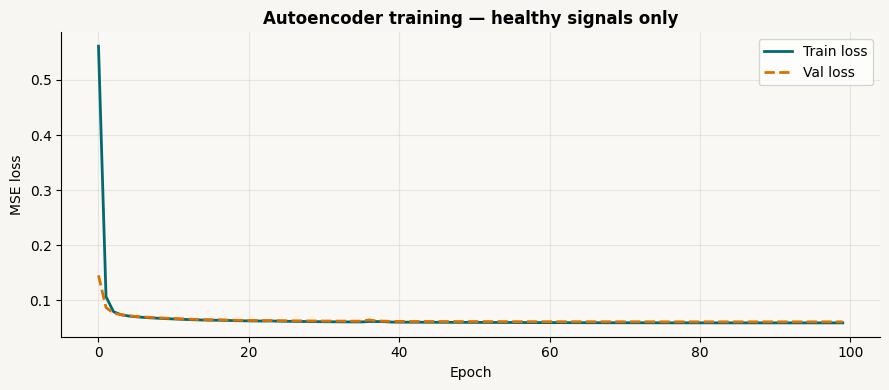

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

history = ae.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

# Plot training curve
fig, ax = plt.subplots(figsize=(9, 4), facecolor='#f7f6f2')
ax.set_facecolor('#f9f8f5')
ax.plot(history.history['loss'],     label='Train loss', color='#01696f', lw=2)
ax.plot(history.history['val_loss'], label='Val loss',   color='#da7101', lw=2, ls='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE loss')
ax.set_title('Autoencoder training — healthy signals only', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.25); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

Threshold τ (p98 healthy MSE) = 0.101579


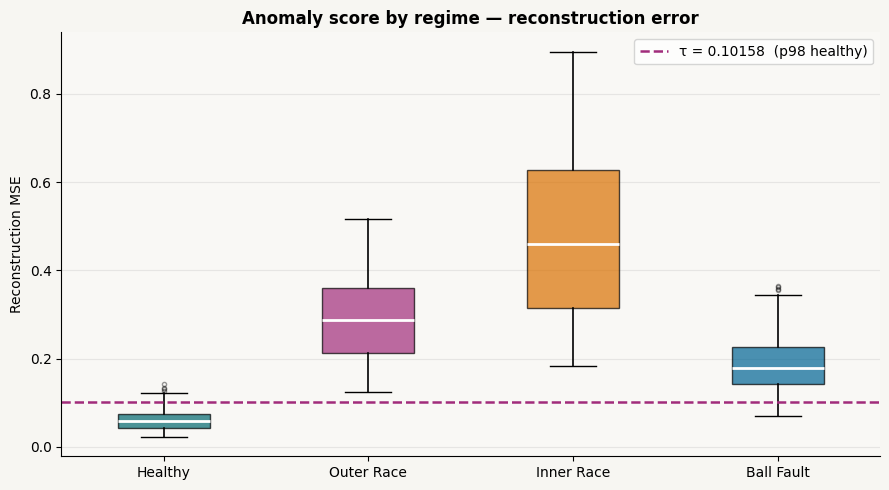


Detection rate (MSE > τ):
  Healthy     : 2.0%
  Outer Race  : 100.0%
  Inner Race  : 100.0%
  Ball Fault  : 95.6%


In [16]:
# Compute per-sample MSE for the full test set
X_test_rec = ae.predict(X_test, verbose=0)
mse = np.mean((X_test - X_test_rec)**2, axis=(1, 2))

# Calibrate threshold on healthy test samples
healthy_mse = mse[y_test == 0]
tau = np.percentile(healthy_mse, 98)
print(f'Threshold τ (p98 healthy MSE) = {tau:.6f}')

# ── Box plot ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5), facecolor='#f7f6f2')
ax.set_facecolor('#f9f8f5')

data_per_regime = [mse[y_test == i] for i in range(4)]
bp = ax.boxplot(data_per_regime, patch_artist=True,
                medianprops=dict(color='white', lw=2),
                whiskerprops=dict(lw=1.2),
                flierprops=dict(marker='o', markersize=3, alpha=0.4))
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.7)

ax.axhline(tau, color='#a12c7b', lw=1.8, ls='--', label=f'τ = {tau:.5f}  (p98 healthy)')
ax.set_xticks(range(1, 5)); ax.set_xticklabels(LABELS, fontsize=10)
ax.set_ylabel('Reconstruction MSE')
ax.set_title('Anomaly score by regime — reconstruction error', fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.25, axis='y')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

# ── Detection rate above τ ───────────────────────────────────────────────
print('\nDetection rate (MSE > τ):')
for i, label in enumerate(LABELS):
    rate = np.mean(mse[y_test == i] > tau)
    print(f'  {label:12s}: {rate:.1%}')

In [17]:
# ---------------------------------------------------------------------
# Synthetic shared-AE result in the same format as the CWRU baselines
# ---------------------------------------------------------------------

X_test_rec = ae.predict(X_test, verbose=0)

mse = np.mean(
    np.square(X_test - X_test_rec),
    axis=(1, 2),
)

THRESHOLD_PERCENTILE = 98.0

healthy_mse = mse[y_test == 0]

tau = float(
    np.percentile(
        healthy_mse,
        THRESHOLD_PERCENTILE,
    )
)

synthetic_ae_results = pd.DataFrame(
    [
        {
            "bearing_id": "Synthetic",
            "detector": "Shared simulator-trained AE",
            "threshold_percentile": THRESHOLD_PERCENTILE,
            "threshold": tau,

            "healthy_far": 100.0 * float(
                np.mean(mse[y_test == 0] > tau)
            ),
            "ball_dr": 100.0 * float(
                np.mean(mse[y_test == 1] > tau)
            ),
            "inner_race_dr": 100.0 * float(
                np.mean(mse[y_test == 2] > tau)
            ),
            "outer_race_dr": 100.0 * float(
                np.mean(mse[y_test == 3] > tau)
            ),

            "n_healthy": int(np.sum(y_test == 0)),
            "n_ball": int(np.sum(y_test == 1)),
            "n_inner_race": int(np.sum(y_test == 2)),
            "n_outer_race": int(np.sum(y_test == 3)),
        }
    ]
)

display(synthetic_ae_results)

,bearing_id,detector,threshold_percentile,threshold,healthy_far,ball_dr,inner_race_dr,outer_race_dr,n_healthy,n_ball,n_inner_race,n_outer_race
0,Synthetic,Shared simulator-trained AE,98.0,0.101579,2.0,100.0,100.0,95.6,750,750,750,750


### DOMAIN ADAPTATION ###

In [18]:
# =====================================================================
# Global experiment parameters
# =====================================================================

TARGET_PERCENTILE = 98.0
WINDOW_SIZE = 100
MIN_WARMUP_SAMPLES = 20
STEP = 1200


# =====================================================================
# Online operational-radius estimator
# =====================================================================

class AdaptiveOperationalRadius:
    """
    Online empirical-quantile estimator.

    The globally shared quantity is the target nominal coverage
    (e.g. 98%), not a z-score or an absolute threshold.

    The local operational radius is estimated as the empirical
    percentile of the accepted nominal residuals.
    """

    def __init__(
        self,
        percentile=98.0,
        window_size=100,
        min_samples=20,
    ):
        if not 0.0 < percentile < 100.0:
            raise ValueError("percentile must be between 0 and 100.")

        if window_size < 2:
            raise ValueError("window_size must be at least 2.")

        if min_samples < 2:
            raise ValueError("min_samples must be at least 2.")

        if min_samples > window_size:
            raise ValueError(
                "min_samples cannot be larger than window_size."
            )

        self.percentile = float(percentile)
        self.window_size = int(window_size)
        self.min_samples = int(min_samples)

        self.buf = deque(maxlen=self.window_size)

    def update(self, mse_value):
        """
        Add one nominal residual and update the operational radius.

        Returns
        -------
        tau : float
            Current operational radius. NaN until min_samples is reached.
        """
        self.buf.append(float(mse_value))

        if len(self.buf) < self.min_samples:
            return np.nan

        arr = np.asarray(self.buf, dtype=np.float64)

        return float(
            np.percentile(
                arr,
                self.percentile,
            )
        )

    def warmup_trace(self, mse_sequence):
        """
        Process an entire warm-up sequence and return tau(t).
        """
        history_tau = []

        for mse_value in mse_sequence:
            history_tau.append(
                self.update(mse_value)
            )

        return np.asarray(history_tau, dtype=np.float64)


# =====================================================================
# Convergence utilities
# =====================================================================

def operational_radius_convergence_trace(
    tau_history,
    *,
    lookback=10,
    eps=1e-12,
):
    """
    Relative variation of tau over a fixed look-back interval.

    C(t) = |tau(t) - tau(t-L)| / max(|tau(t-L)|, eps)
    """
    tau_history = np.asarray(tau_history, dtype=np.float64)

    convergence = np.full(
        tau_history.shape,
        np.nan,
        dtype=np.float64,
    )

    for t in range(lookback, len(tau_history)):
        current = tau_history[t]
        previous = tau_history[t - lookback]

        if np.isfinite(current) and np.isfinite(previous):
            convergence[t] = (
                abs(current - previous)
                / max(abs(previous), eps)
            )

    return convergence


def find_convergence_index(
    tau_history,
    *,
    lookback=10,
    tolerance=0.01,
    consecutive=10,
):
    """
    Return the first index at which the operational radius remains
    stable for `consecutive` updates.

    Returns None when convergence is not observed.
    """
    convergence = operational_radius_convergence_trace(
        tau_history,
        lookback=lookback,
    )

    stable_count = 0

    for t, value in enumerate(convergence):
        if np.isfinite(value) and value < tolerance:
            stable_count += 1

            if stable_count >= consecutive:
                return t
        else:
            stable_count = 0

    return None


# =====================================================================
# Shared simulator-trained AE applied unchanged to CWRU
# =====================================================================

def run_experiment(
    bearing_id,
    *,
    target_percentile=TARGET_PERCENTILE,
    warmup_size=100,
    operational_window_size=WINDOW_SIZE,
    min_warmup_samples=MIN_WARMUP_SAMPLES,
    convergence_lookback=10,
    convergence_tolerance=0.01,
    convergence_consecutive=10,
):
    """
    Evaluate the simulator-trained shared AE on one CWRU condition.

    Important
    ---------
    - `ae` and `scaler` are the models trained on synthetic healthy data.
    - They are transferred unchanged to CWRU.
    - All CWRU healthy windows are used only for the field-oracle p98.
    - Only the first `warmup_size` healthy windows are used by the
      online operational-radius estimator.
    """

    # -----------------------------------------------------------------
    # Load complete CWRU signals
    # -----------------------------------------------------------------

    normal_signal = load_cwru_signal(bearing_id, "healthy")
    ball_signal   = load_cwru_signal(bearing_id, "ball")
    inner_signal  = load_cwru_signal(bearing_id, "inner")
    outer_signal  = load_cwru_signal(bearing_id, "outer")

    print(f"\nCWRU operating condition: {bearing_id} RPM")
    print("Normal:", normal_signal.shape)
    print("Ball:  ", ball_signal.shape)
    print("Inner: ", inner_signal.shape)
    print("Outer: ", outer_signal.shape)

    # -----------------------------------------------------------------
    # Apply synthetic scaler and shared AE unchanged
    # -----------------------------------------------------------------

    def cwru_mse(signal):
        windows = make_windows(
            signal,
            win=SIG_LEN,
            step=STEP,
        )

        windows_2d = windows.reshape(
            windows.shape[0],
            -1,
        )

        # This scaler was fitted on synthetic nominal data.
        windows_scaled = scaler.transform(
            windows_2d
        )

        X = windows_scaled[
            :,
            :,
            np.newaxis,
        ].astype(np.float32)

        X_rec = ae.predict(
            X,
            verbose=0,
        )

        return np.mean(
            np.square(X - X_rec),
            axis=(1, 2),
        )

    # -----------------------------------------------------------------
    # Synthetic absolute threshold
    # -----------------------------------------------------------------

    X_train_rec = ae.predict(
        X_train,
        verbose=0,
    )

    mse_mc_healthy = np.mean(
        np.square(X_train - X_train_rec),
        axis=(1, 2),
    )

    tau_mc = float(
        np.percentile(
            mse_mc_healthy,
            target_percentile,
        )
    )

    # -----------------------------------------------------------------
    # CWRU residuals
    # -----------------------------------------------------------------

    mse_healthy = cwru_mse(normal_signal)
    mse_ball = cwru_mse(ball_signal)
    mse_inner = cwru_mse(inner_signal)
    mse_outer = cwru_mse(outer_signal)

    print(
        "Windows → "
        f"healthy:{len(mse_healthy)} "
        f"ball:{len(mse_ball)} "
        f"inner:{len(mse_inner)} "
        f"outer:{len(mse_outer)}"
    )

    # -----------------------------------------------------------------
    # Field oracle: all available healthy CWRU windows
    # -----------------------------------------------------------------

    tau_field_oracle = float(
        np.percentile(
            mse_healthy,
            target_percentile,
        )
    )

    # -----------------------------------------------------------------
    # Online field deployment: only initial healthy warm-up
    # -----------------------------------------------------------------

    if warmup_size is None:
        warmup_size = len(mse_healthy)

    warmup_size = min(
        int(warmup_size),
        len(mse_healthy),
    )

    if warmup_size < min_warmup_samples:
        raise ValueError(
            f"warmup_size={warmup_size} is smaller than "
            f"min_warmup_samples={min_warmup_samples}."
        )

    mse_warmup = mse_healthy[:warmup_size]

    adaptive = AdaptiveOperationalRadius(
        percentile=target_percentile,
        window_size=min(
            operational_window_size,
            warmup_size,
        ),
        min_samples=min(
            min_warmup_samples,
            warmup_size,
        ),
    )

    tau_history = adaptive.warmup_trace(
        mse_warmup
    )

    valid_tau = tau_history[
        np.isfinite(tau_history)
    ]

    if len(valid_tau) == 0:
        raise RuntimeError(
            "The online operational radius did not initialize."
        )

    tau_online = float(valid_tau[-1])

    convergence_index = find_convergence_index(
        tau_history,
        lookback=convergence_lookback,
        tolerance=convergence_tolerance,
        consecutive=convergence_consecutive,
    )

    # -----------------------------------------------------------------
    # Metrics
    # -----------------------------------------------------------------

    def alarm_rate(scores, threshold):
        return 100.0 * float(
            np.mean(scores > threshold)
        )

    thresholds = {
        "absolute_mc": tau_mc,
        "field_oracle": tau_field_oracle,
        "online_radius": tau_online,
    }

    rows = []

    for threshold_name, threshold_value in thresholds.items():
        rows.append(
            {
                "bearing_id": str(bearing_id),
                "detector": "Shared simulator-trained AE",
                "calibration": threshold_name,
                "threshold_percentile": target_percentile,
                "threshold": threshold_value,

                "healthy_far": alarm_rate(
                    mse_healthy,
                    threshold_value,
                ),
                "ball_dr": alarm_rate(
                    mse_ball,
                    threshold_value,
                ),
                "inner_race_dr": alarm_rate(
                    mse_inner,
                    threshold_value,
                ),
                "outer_race_dr": alarm_rate(
                    mse_outer,
                    threshold_value,
                ),

                "n_healthy": len(mse_healthy),
                "n_ball": len(mse_ball),
                "n_inner_race": len(mse_inner),
                "n_outer_race": len(mse_outer),

                "warmup_size": (
                    0
                    if threshold_name == "absolute_mc"
                    else (
                        len(mse_healthy)
                        if threshold_name == "field_oracle"
                        else warmup_size
                    )
                ),

                "convergence_index": (
                    convergence_index
                    if threshold_name == "online_radius"
                    else np.nan
                ),
            }
        )

    results_table = pd.DataFrame(rows)

    print("\nThresholds")
    print(f"τ_MC absolute       = {tau_mc:.6f}")
    print(f"τ_field oracle p98 = {tau_field_oracle:.6f}")
    print(f"τ_online           = {tau_online:.6f}")

    if convergence_index is None:
        print("Operational-radius convergence: not detected")
    else:
        print(
            "Operational-radius convergence detected at "
            f"warm-up window {convergence_index}."
        )

    display(results_table)

    return {
        "bearing_id": str(bearing_id),

        "mse_mc_healthy": mse_mc_healthy,
        "mse_healthy": mse_healthy,
        "mse_ball": mse_ball,
        "mse_inner": mse_inner,
        "mse_outer": mse_outer,

        "mse_warmup": mse_warmup,
        "tau_history": tau_history,

        "tau_mc": tau_mc,
        "tau_field_oracle": tau_field_oracle,
        "tau_online": tau_online,

        "convergence_index": convergence_index,
        "results_table": results_table,
    }


# =====================================================================
# Plotting
# =====================================================================

def plot_experiment(result):
    """
    Plot field residual distribution and online radius convergence.
    """

    bearing_id = result["bearing_id"]

    mse_healthy = result["mse_healthy"]
    mse_warmup = result["mse_warmup"]

    tau_mc = result["tau_mc"]
    tau_field_oracle = result["tau_field_oracle"]
    tau_online = result["tau_online"]

    tau_history = result["tau_history"]
    convergence_index = result["convergence_index"]

    # -----------------------------------------------------------------
    # Healthy residual distribution
    # -----------------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(10, 5)
    )

    ax.hist(
        mse_healthy,
        bins=50,
        density=True,
        alpha=0.60,
        label="Healthy CWRU",
    )

    ax.axvline(
        tau_mc,
        linestyle="--",
        linewidth=1.5,
        label=f"Absolute simulator τ = {tau_mc:.4f}",
    )

    ax.axvline(
        tau_field_oracle,
        linestyle="--",
        linewidth=1.5,
        label=f"Field oracle p98 = {tau_field_oracle:.4f}",
    )

    ax.axvline(
        tau_online,
        linestyle="--",
        linewidth=1.5,
        label=f"Online radius = {tau_online:.4f}",
    )

    ax.set_xlabel("Reconstruction MSE")
    ax.set_ylabel("Density")
    ax.set_title(
        f"Healthy CWRU residual distribution — {bearing_id} RPM"
    )

    ax.legend()
    ax.grid(
        True,
        alpha=0.25,
        axis="y",
    )

    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------------------
    # Operational-radius convergence
    # -----------------------------------------------------------------

    steps = np.arange(
        len(tau_history)
    )

    fig, ax = plt.subplots(
        figsize=(11, 5)
    )

    ax.plot(
        steps,
        tau_history,
        linewidth=1.5,
        label="Online operational radius",
    )

    ax.axhline(
        tau_field_oracle,
        linestyle="--",
        linewidth=1.2,
        label=f"Full-data field oracle = {tau_field_oracle:.4f}",
    )

    if convergence_index is not None:
        ax.axvline(
            convergence_index,
            linestyle=":",
            linewidth=1.2,
            label=f"Convergence = {convergence_index}",
        )

    ax.set_xlabel("Healthy warm-up window")
    ax.set_ylabel("Operational radius")
    ax.set_title(
        f"Operational-radius convergence — {bearing_id} RPM"
    )

    ax.legend()
    ax.grid(
        True,
        alpha=0.25,
    )

    plt.tight_layout()
    plt.show()

    print(
        f"Full healthy windows: {len(mse_healthy)}\n"
        f"Online warm-up windows: {len(mse_warmup)}\n"
        f"Field oracle p98: {tau_field_oracle:.6f}\n"
        f"Online radius: {tau_online:.6f}"
    )


CWRU operating condition: 1797 RPM
Normal: (243938, 1)
Ball:   (487209, 1)
Inner:  (486048, 1)
Outer:  (854372, 1)
Windows → healthy:203 ball:406 inner:405 outer:711

Thresholds
τ_MC absolute       = 0.097945
τ_field oracle p98 = 0.247356
τ_online           = 0.236354
Operational-radius convergence detected at warm-up window 65.


,bearing_id,detector,calibration,threshold_percentile,threshold,healthy_far,ball_dr,inner_race_dr,outer_race_dr,n_healthy,n_ball,n_inner_race,n_outer_race,warmup_size,convergence_index
0,1797,Shared simulator-trained AE,absolute_mc,98.0,0.097945,100.000000,100.000000,100.0,100.0,203,406,405,711,0,NaN
1,1797,Shared simulator-trained AE,field_oracle,98.0,0.247356,2.463054,96.798030,100.0,100.0,203,406,405,711,203,NaN
2,1797,Shared simulator-trained AE,online_radius,98.0,0.236354,5.911330,98.768473,100.0,100.0,203,406,405,711,100,65.0


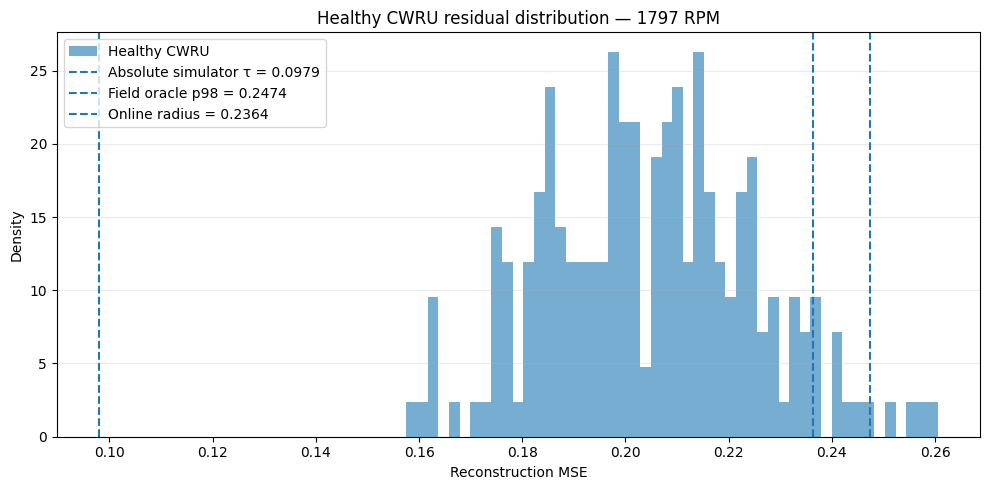

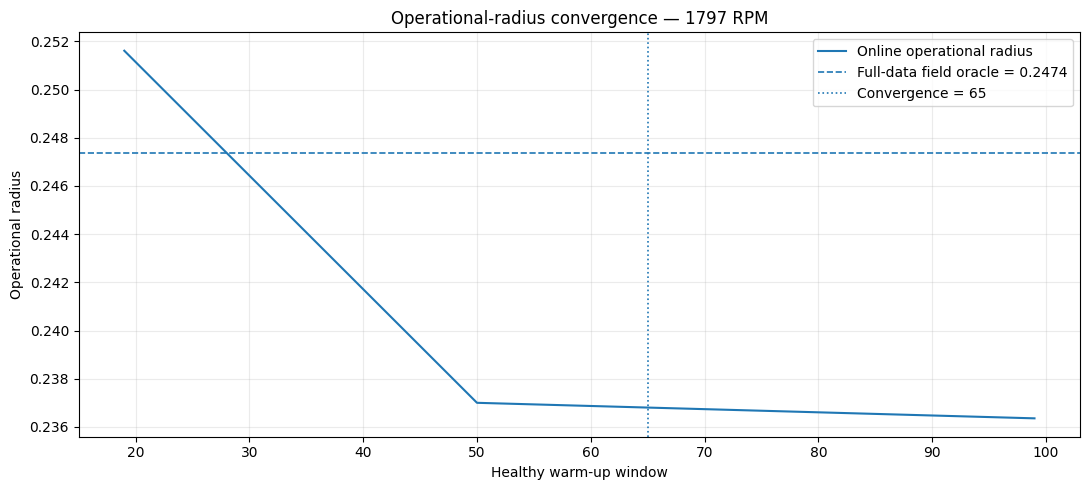

Full healthy windows: 203
Online warm-up windows: 100
Field oracle p98: 0.247356
Online radius: 0.236354


In [19]:
result_1797 = run_experiment(
    "1797",
    target_percentile=98.0,
    warmup_size=100,
    operational_window_size=100,
    min_warmup_samples=20,
)

plot_experiment(result_1797)

In [20]:
shared_results = []
shared_tables = []

for bearing_id in BEARING_IDS:
    result = run_experiment(
        bearing_id,
        target_percentile=98.0,
        warmup_size=100,
        operational_window_size=100,
        min_warmup_samples=20,
    )

    shared_results.append(result)
    shared_tables.append(
        result["results_table"]
    )

shared_method_table = pd.concat(
    shared_tables,
    ignore_index=True,
)

display(shared_method_table)


CWRU operating condition: 1730 RPM
Normal: (485643, 1)
Ball:   (486812, 1)
Inner:  (488144, 1)
Outer:  (854807, 1)
Windows → healthy:404 ball:405 inner:406 outer:712

Thresholds
τ_MC absolute       = 0.097945
τ_field oracle p98 = 0.200544
τ_online           = 0.198352
Operational-radius convergence detected at warm-up window 38.


,bearing_id,detector,calibration,threshold_percentile,threshold,healthy_far,ball_dr,inner_race_dr,outer_race_dr,n_healthy,n_ball,n_inner_race,n_outer_race,warmup_size,convergence_index
0,1730,Shared simulator-trained AE,absolute_mc,98.0,0.097945,100.000000,100.0,100.0,100.0,404,405,406,712,0,NaN
1,1730,Shared simulator-trained AE,field_oracle,98.0,0.200544,2.227723,100.0,100.0,100.0,404,405,406,712,404,NaN
2,1730,Shared simulator-trained AE,online_radius,98.0,0.198352,2.970297,100.0,100.0,100.0,404,405,406,712,100,38.0



CWRU operating condition: 1750 RPM
Normal: (485063, 1)
Ball:   (486667, 1)
Inner:  (487179, 1)
Outer:  (854371, 1)
Windows → healthy:404 ball:405 inner:405 outer:711

Thresholds
τ_MC absolute       = 0.097945
τ_field oracle p98 = 0.178633
τ_online           = 0.175879
Operational-radius convergence detected at warm-up window 58.


,bearing_id,detector,calibration,threshold_percentile,threshold,healthy_far,ball_dr,inner_race_dr,outer_race_dr,n_healthy,n_ball,n_inner_race,n_outer_race,warmup_size,convergence_index
0,1750,Shared simulator-trained AE,absolute_mc,98.0,0.097945,100.000000,100.0,100.0,100.0,404,405,405,711,0,NaN
1,1750,Shared simulator-trained AE,field_oracle,98.0,0.178633,2.227723,100.0,100.0,100.0,404,405,405,711,404,NaN
2,1750,Shared simulator-trained AE,online_radius,98.0,0.175879,2.970297,100.0,100.0,100.0,404,405,405,711,100,58.0



CWRU operating condition: 1772 RPM
Normal: (483903, 1)
Ball:   (486598, 1)
Inner:  (486744, 1)
Outer:  (854807, 1)
Windows → healthy:403 ball:405 inner:405 outer:712

Thresholds
τ_MC absolute       = 0.097945
τ_field oracle p98 = 0.199741
τ_online           = 0.207229
Operational-radius convergence detected at warm-up window 43.


,bearing_id,detector,calibration,threshold_percentile,threshold,healthy_far,ball_dr,inner_race_dr,outer_race_dr,n_healthy,n_ball,n_inner_race,n_outer_race,warmup_size,convergence_index
0,1772,Shared simulator-trained AE,absolute_mc,98.0,0.097945,100.000000,100.0,100.0,100.0,403,405,405,712,0,NaN
1,1772,Shared simulator-trained AE,field_oracle,98.0,0.199741,2.233251,100.0,100.0,100.0,403,405,405,712,403,NaN
2,1772,Shared simulator-trained AE,online_radius,98.0,0.207229,0.496278,100.0,100.0,100.0,403,405,405,712,100,43.0



CWRU operating condition: 1797 RPM
Normal: (243938, 1)
Ball:   (487209, 1)
Inner:  (486048, 1)
Outer:  (854372, 1)
Windows → healthy:203 ball:406 inner:405 outer:711

Thresholds
τ_MC absolute       = 0.097945
τ_field oracle p98 = 0.247356
τ_online           = 0.236354
Operational-radius convergence detected at warm-up window 65.


,bearing_id,detector,calibration,threshold_percentile,threshold,healthy_far,ball_dr,inner_race_dr,outer_race_dr,n_healthy,n_ball,n_inner_race,n_outer_race,warmup_size,convergence_index
0,1797,Shared simulator-trained AE,absolute_mc,98.0,0.097945,100.000000,100.000000,100.0,100.0,203,406,405,711,0,NaN
1,1797,Shared simulator-trained AE,field_oracle,98.0,0.247356,2.463054,96.798030,100.0,100.0,203,406,405,711,203,NaN
2,1797,Shared simulator-trained AE,online_radius,98.0,0.236354,5.911330,98.768473,100.0,100.0,203,406,405,711,100,65.0


,bearing_id,detector,calibration,threshold_percentile,threshold,healthy_far,ball_dr,inner_race_dr,outer_race_dr,n_healthy,n_ball,n_inner_race,n_outer_race,warmup_size,convergence_index
0,1730,Shared simulator-trained AE,absolute_mc,98.0,0.097945,100.000000,100.000000,100.0,100.0,404,405,406,712,0,NaN
1,1730,Shared simulator-trained AE,field_oracle,98.0,0.200544,2.227723,100.000000,100.0,100.0,404,405,406,712,404,NaN
2,1730,Shared simulator-trained AE,online_radius,98.0,0.198352,2.970297,100.000000,100.0,100.0,404,405,406,712,100,38.0
3,1750,Shared simulator-trained AE,absolute_mc,98.0,0.097945,100.000000,100.000000,100.0,100.0,404,405,405,711,0,NaN
4,1750,Shared simulator-trained AE,field_oracle,98.0,0.178633,2.227723,100.000000,100.0,100.0,404,405,405,711,404,NaN
5,1750,Shared simulator-trained AE,online_radius,98.0,0.175879,2.970297,100.000000,100.0,100.0,404,405,405,711,100,58.0
6,1772,Shared simulator-trained AE,absolute_mc,98.0,0.097945,100.000000,100.000000,100.0,100.0,403,405,405,712,0,NaN
7,1772,Shared simulator-trained AE,field_oracle,98.0,0.199741,2.233251,100.000000,100.0,100.0,403,405,405,712,403,NaN
8,1772,Shared simulator-trained AE,online_radius,98.0,0.207229,0.496278,100.000000,100.0,100.0,403,405,405,712,100,43.0
9,1797,Shared simulator-trained AE,absolute_mc,98.0,0.097945,100.000000,100.000000,100.0,100.0,203,406,405,711,0,NaN
